In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [32]:
import joblib

In [2]:
os.makedirs('data', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)
os.makedirs('models', exist_ok=True)

os.makedirs('results/Eda_graphs', exist_ok=True)
os.makedirs('results/final_data', exist_ok=True)
os.makedirs('results/metrices', exist_ok=True)
os.makedirs('results/result_graphs', exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [28]:
df = pd.read_csv('Telco-Customer-Churn.csv')

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN values in 'TotalCharges' with the median, if any
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.shape

(7043, 21)

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [25]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2526/832047620.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2526/832047620.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

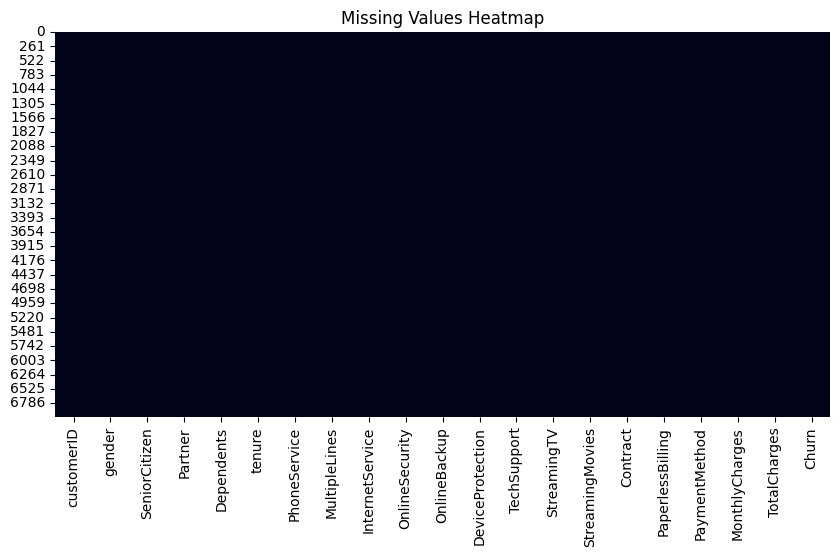

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.savefig('results/Eda_graphs/missing_values.png')
plt.show()

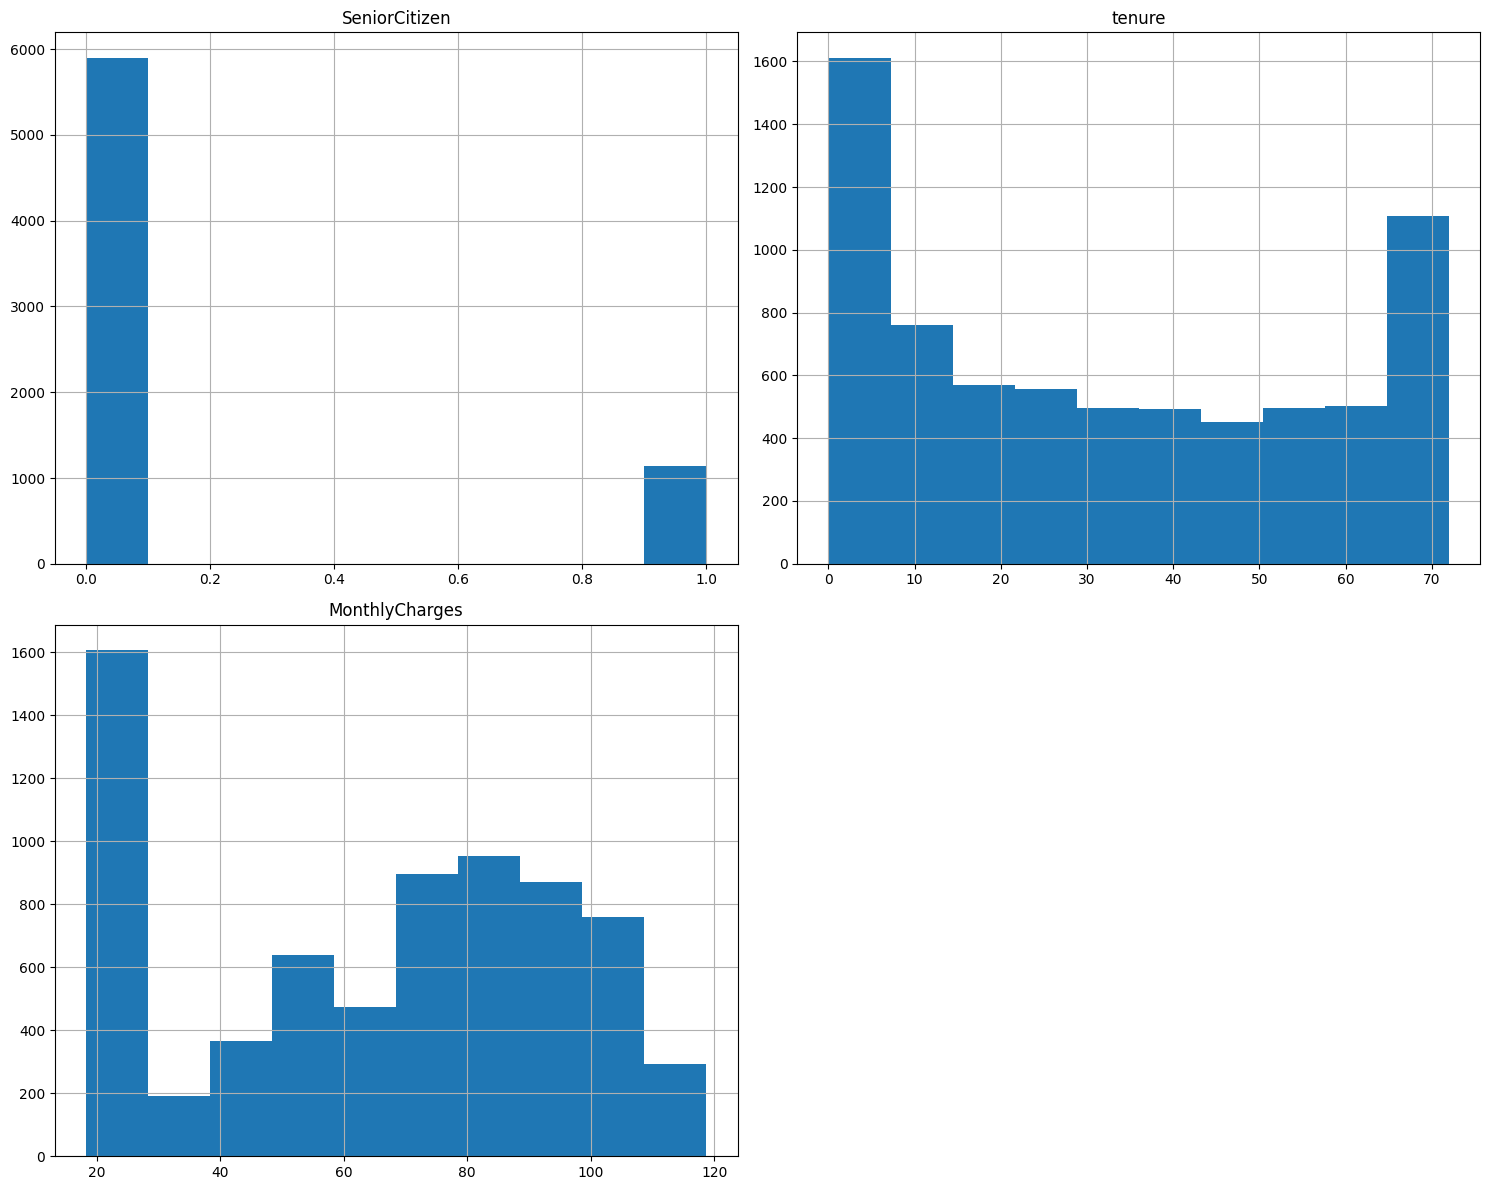

In [10]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.savefig('results/Eda_graphs/histograms.png')
plt.show()

In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [33]:
# Drop the 'customerID' column as it's a unique identifier and not a predictive feature.
df_processed = df.drop('customerID', axis=1)
df_encoded = pd.get_dummies(df_processed, drop_first=True)

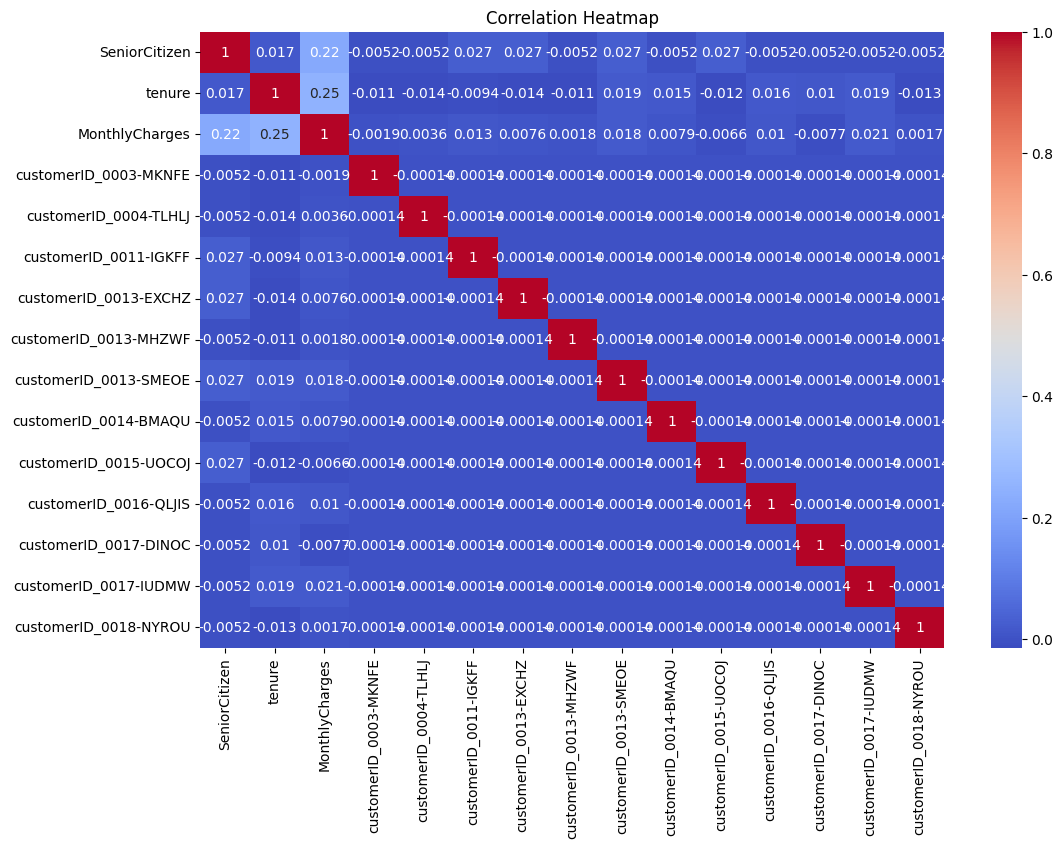

In [12]:
plt.figure(figsize=(12,8))
corr = df_encoded.iloc[:, :15].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('results/Eda_graphs/correlation_heatmap.png')
plt.show()

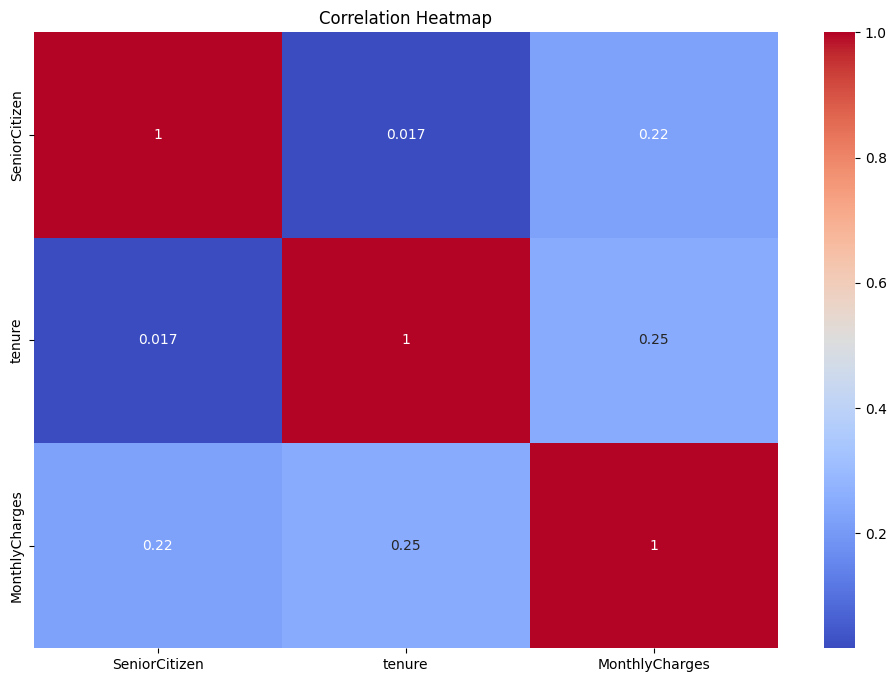

In [13]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('results/Eda_graphs/correlation_heatmap.png')
plt.show()

In [14]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
print("X Train:", x_train.shape)
print("X Test:", x_test.shape)
print("Y Train:", y_train.shape)
print("Y Test:", y_test.shape)

X Train: (5634, 13601)
X Test: (1409, 13601)
Y Train: (5634,)
Y Test: (1409,)


In [17]:
x_train.to_csv(
    'results/final_data/x_train.csv',
    index=False
)

x_test.to_csv(
    'results/final_data/x_test.csv',
    index=False
)

y_train.to_frame().to_csv(
    'results/final_data/y_train.csv',
    index=False
)

y_test.to_frame().to_csv(
    'results/final_data/y_test.csv',
    index=False
)

In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred = model.predict(x_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8034066713981547

              precision    recall  f1-score   support

       False       0.83      0.93      0.87      1036
        True       0.70      0.45      0.55       373

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



In [21]:
with open('results/metrices/metrics.txt', 'w') as f:
    f.write(f'Accuracy: {accuracy}\n\n')
    f.write(classification_report(y_test, y_pred))

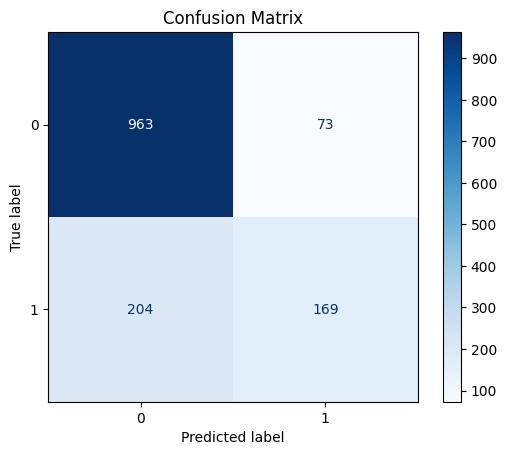

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix')

plt.savefig(
    'results/result_graphs/confusion_matrix.png'
)

plt.show()

In [23]:
with open('models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [34]:
# Save the model using joblib with compression
joblib.dump(model, 'models/model.pkl', compress=3)

print("Model saved successfully using joblib with compression!")

Model saved successfully using joblib with compression!


In [ ]:
model_size_bytes = os.path.getsize('models/model.pkl')
model_size_mb = model_size_bytes / (1024 * 1024)
print(f"New model size: {model_size_mb:.2f} MB")

if model_size_mb < 25:
    print("Model size is less than 25 MB. Goal achieved!")
else:
    print("Model size is still 25 MB or more. Further optimization might be needed.")

In [24]:
print(os.listdir('results/final_data'))
print(os.listdir('results/Eda_graphs'))
print(os.listdir('results/metrices'))
print(os.listdir('results/result_graphs'))
print(os.listdir('models'))

['x_train.csv', 'y_test.csv', 'y_train.csv', 'x_test.csv']
['correlation_heatmap.png', 'missing_values.png', 'histograms.png']
['metrics.txt']
['confusion_matrix.png']
['model.pkl']


In [31]:
with open('results/final_data/data_info.txt', 'w') as f:
    f.write(f"X_train shape: {x_train.shape}\n")
    f.write(f"X_test shape: {x_test.shape}\n")
    f.write(f"Y_train shape: {y_train.shape}\n")
    f.write(f"Y_test shape: {y_test.shape}\n")